# **Grover's Algorithm: 2-Qubit Search**

Grover's algorithm is a quantum search algorithm that can find a marked item in an unstructured search space using amplitude amplification.

In this notebook, we implement Grover's algorithm for a two-qubit search space containing four possible states:

$$
|00\rangle,\quad |01\rangle,\quad |10\rangle,\quad |11\rangle.
$$

A single state is marked by the oracle. The algorithm uses an oracle followed by a diffusion operator to amplify the amplitude of the marked state.

The implementation is tested using an ideal quantum simulator.

## Introduction

Suppose we have an unstructured collection of $N$ possible states and want to find one particular marked state.

A classical search may require checking the states one by one. On average, this requires a number of queries proportional to $N$.

Grover's algorithm provides a quantum approach that requires approximately

$$
O(\sqrt{N})
$$

oracle queries.

For this notebook, we use two qubits, giving

$$
N=2^2=4
$$

possible states. The marked state is initially chosen to be `11`.

## Theory

### Initial superposition

The algorithm begins by applying Hadamard gates to both qubits:

$$
|00\rangle
\rightarrow
\frac{1}{2}
\left(
|00\rangle+|01\rangle+|10\rangle+|11\rangle
\right).
$$

Each state therefore has the same initial amplitude:

$$
\frac{1}{2}.
$$

The goal of Grover's algorithm is to increase the amplitude of the marked state while reducing the amplitudes of the other states.

### Oracle

The oracle identifies the marked state by applying a phase flip:

$$
O|w\rangle=-|w\rangle,
$$

where $|w\rangle$ is the marked state.

All other computational basis states are left unchanged.

For example, if the marked state is $|11\rangle$, the oracle transforms

$$
\frac{1}{2}
\left(
|00\rangle+|01\rangle+|10\rangle+|11\rangle
\right)
$$

into

$$
\frac{1}{2}
\left(
|00\rangle+|01\rangle+|10\rangle-|11\rangle
\right).
$$

The oracle therefore does not directly increase the probability of the marked state. Instead, it changes its phase so that the following diffusion operation can amplify its amplitude.

### Diffusion operator

The diffusion operator performs an inversion about the mean of the amplitudes.

It can be written as

$$
D=2|s\rangle\langle s|-I,
$$

where $|s\rangle$ is the equal superposition state

$$
|s\rangle=
\frac{1}{2}
\left(
|00\rangle+|01\rangle+|10\rangle+|11\rangle
\right).
$$

After the oracle has changed the sign of the marked state's amplitude, the diffusion operator reflects the amplitudes about their mean.

This increases the amplitude of the marked state and decreases the amplitudes of the unmarked states.

The combination

$$
\boxed{\text{Oracle} \rightarrow \text{Diffusion}}
$$

is known as a Grover iteration.

### Number of iterations

For a search space containing $N$ states, the approximately optimal number of Grover iterations is

$$
r\approx\frac{\pi}{4}\sqrt{N}.
$$

Here,

$$
N=4,
$$

so

$$
\frac{\pi}{4}\sqrt{4}
=
\frac{\pi}{2}
\approx1.57.
$$

Therefore, one integer iteration is appropriate for this two-qubit example.

After one Grover iteration, the ideal circuit should produce the marked state with probability 1.

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def marked_state_oracle(marked: str) -> QuantumCircuit:
    """
    Construct a phase oracle for a two-qubit marked state.

    Parameters
    ----------
    marked : str
        Two-bit string representing the marked computational basis state.

    Returns
    -------
    QuantumCircuit
        Two-qubit oracle that flips the phase of the marked state.
    """

    qc = QuantumCircuit(2)

    # Reverse the string to match Qiskit's little-endian qubit ordering.
    reversed_marked = marked[::-1]

    # Map the marked state to |11>.
    for i, bit in enumerate(reversed_marked):
        if bit == '0':
            qc.x(i)

    # Apply a phase flip to |11>.
    qc.cz(0, 1)

    # Undo the temporary X gates.
    for i, bit in enumerate(reversed_marked):
        if bit == '0':
            qc.x(i)

    return qc

In [15]:
def diffusion_operator() -> QuantumCircuit:
    """
    Construct the two-qubit Grover diffusion operator.
    """

    qc = QuantumCircuit(2)

    qc.h([0, 1])
    qc.append(marked_state_oracle('00').to_gate(), [0, 1])
    qc.h([0, 1])

    return qc

In [16]:
def build_grover_circuit(marked: str, iterations: int = 1) -> QuantumCircuit:
    """
    Construct a two-qubit Grover search circuit.

    Parameters
    ----------
    marked : str
        Two-bit string representing the marked state.
    iterations : int
        Number of Grover iterations.

    Returns
    -------
    QuantumCircuit
        Grover search circuit with measurements.
    """

    qc = QuantumCircuit(2, 2)

    # Prepare an equal superposition of all four states.
    qc.h([0, 1])

    oracle = marked_state_oracle(marked)
    diffusion = diffusion_operator()

    # Apply the Grover iterations.
    for _ in range(iterations):
        qc.append(oracle.to_gate(), [0, 1])
        qc.append(diffusion.to_gate(), [0, 1])

    qc.measure([0, 1], [0, 1])

    return qc

In [17]:
marked = '11'

grover_circuit = build_grover_circuit(marked, iterations=1)

print(grover_circuit.draw())

     ┌───┐┌─────────────┐┌─────────────┐┌─┐   
q_0: ┤ H ├┤0            ├┤0            ├┤M├───
     ├───┤│  circuit-89 ││  circuit-90 │└╥┘┌─┐
q_1: ┤ H ├┤1            ├┤1            ├─╫─┤M├
     └───┘└─────────────┘└─────────────┘ ║ └╥┘
c: 2/════════════════════════════════════╩══╩═
                                         0  1 


In [18]:
simulator = AerSimulator()
shots = 1024

compiled = transpile(grover_circuit, simulator)

result = simulator.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

print(counts)

{'11': 1024}


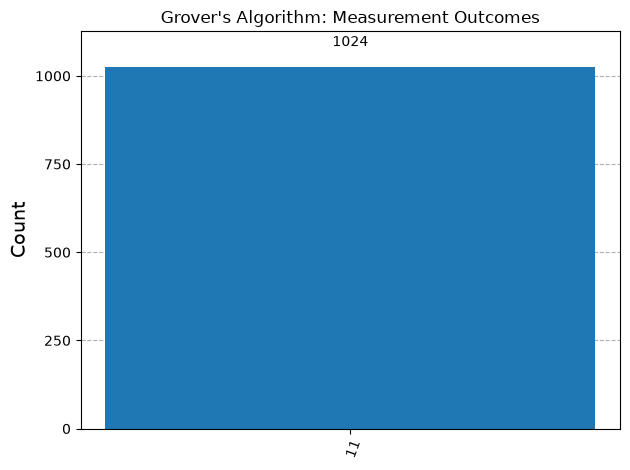

In [19]:
fig = plot_histogram(
    counts,
    title="Grover's Algorithm: Measurement Outcomes"
)

fig.savefig(
    "../assets/grover_2qubit_histogram.png",
    dpi=200,
    bbox_inches="tight"
)

display(fig)

## Results

The circuit was run for 1024 shots with `11` as the marked state.

The simulation produced:

| State | Counts | Measured probability |
|:-----:|-------:|---------------------:|
| `00` | 0 | 0% |
| `01` | 0 | 0% |
| `10` | 0 | 0% |
| `11` | 1024 | 100% |

The marked state `11` was therefore measured in every shot.

For the ideal two-qubit Grover circuit, one iteration is expected to amplify the marked state to probability 1. The simulation agrees exactly with this prediction.

## Discussion

The simulation demonstrates the amplitude amplification mechanism of Grover's algorithm.

Initially, all four computational basis states have equal amplitude. The oracle changes the sign of the marked state's amplitude but does not change its probability. The diffusion operator then performs an inversion about the mean, increasing the marked state's amplitude while reducing the amplitudes of the unmarked states.

After one Grover iteration, the amplitude of the marked state is 1 and the amplitudes of the other three states are 0. Consequently, the marked state `11` was measured in all 1024 shots.

This result was obtained using an ideal quantum simulator, so no hardware noise or other experimental errors were present.

The example also illustrates why Grover's algorithm is described as an amplitude amplification algorithm: the oracle identifies the desired state through its phase, while the diffusion operation converts this phase difference into a difference in measurement probability.

## Conclusion

Grover's algorithm was successfully implemented for a two-qubit search space containing four possible states.

With `11` chosen as the marked state, a single Grover iteration amplified its probability to 100% in the ideal simulation. The marked state was therefore measured in all 1024 shots.

This example demonstrates the central idea of Grover's algorithm: a phase oracle and diffusion operator can be combined to amplify the amplitude of a desired state, allowing it to be identified through measurement.